In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading and preprocessing data

In [13]:
df_hicp = pd.read_csv("data_raw/hicp.csv")
df_deposit_facility_rate = pd.read_csv("data_raw/deposit_facility_rate.csv")
df_unemployment_rate = pd.read_csv("data_raw/unemployment_rate.csv")
df_m3_growth = pd.read_csv("data_raw/M3_growth.csv")
df_euribor_3m = pd.read_csv("data_raw/euribor_3months.csv")
df_btc_price = pd.read_csv("data_raw/btc_price.csv",sep=";")
df_gold = pd.read_csv("data_raw/gold_price.csv")


#ok
df_hicp["OBS_VALUE"] = df_hicp["OBS_VALUE"].pct_change(12) * 100
df_hicp = df_hicp.loc[(df_hicp["TIME_PERIOD"]<="2026")&(df_hicp["TIME_PERIOD"]>="2021")]
df_hicp = df_hicp.loc[(df_hicp["coicop"]=="All-items HICP") & (df_hicp["geo"]=="European Union - 27 countries (from 2020)") & (df_hicp["unit"]=="Index, 2015=100")]
df_hicp = df_hicp.loc[:,["TIME_PERIOD","OBS_VALUE"]].rename(columns={"TIME_PERIOD": "Date","OBS_VALUE": "HICP"})



###################################
df_deposit_facility_rate = df_deposit_facility_rate.loc[:, ["DATE", "Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)"]]\
    .rename(columns={"DATE": "Date", "Main refinancing operations - Minimum bid rate/fixed rate (date of changes) - Level (FM.D.U2.EUR.4F.KR.MRR_RT.LEV)": "MRO"})
#preprocess deposit facility rate
df_deposit_facility_rate = df_deposit_facility_rate.loc[df_deposit_facility_rate["Date"]>="2021"]
df_deposit_facility_rate = df_deposit_facility_rate.loc[df_deposit_facility_rate["Date"]<="2026"]


if len(df_deposit_facility_rate["Date"].iloc[0])>=7:
    df_deposit_facility_rate["Date"]=df_deposit_facility_rate["Date"].apply(lambda x : x[0:7])

df_deposit_facility_rate=df_deposit_facility_rate.groupby(["Date"]).mean()
###################

df_unemployment_rate = df_unemployment_rate.loc[df_unemployment_rate["observation_date"]<="2026"]
df_unemployment_rate = df_unemployment_rate.loc[df_unemployment_rate["observation_date"]>="2021"]\
    .rename(columns={"observation_date": "Date","# UNRATE":"unemp_rate"})
if len(df_unemployment_rate["Date"].iloc[0])>=7:
    df_unemployment_rate["Date"]=df_unemployment_rate["Date"].apply(lambda x : x[0:7])

#####################

df_m3_growth=df_m3_growth.loc[(df_m3_growth["DATE"]>="2021") & (df_m3_growth["DATE"]<="2026")]\
    .loc[:,["DATE","Monetary aggregate M3, Annual growth rate (BSI.M.U2.Y.V.M30.X.I.U2.2300.Z01.A)"]]\
        .rename(columns={"DATE": "Date", "Monetary aggregate M3, Annual growth rate (BSI.M.U2.Y.V.M30.X.I.U2.2300.Z01.A)": "M3_growth"})
if len(df_m3_growth["Date"].iloc[0])>=7:
    df_m3_growth["Date"]=df_m3_growth["Date"].apply(lambda x : x[0:7])

##########################

df_euribor_3m = df_euribor_3m.loc[df_euribor_3m["DATE"]>="2021"]
df_euribor_3m = df_euribor_3m.loc[df_euribor_3m["DATE"]<="2026"]
df_euribor_3m = df_euribor_3m.loc[:,["DATE","Euribor 3-month - Historical close, average of observations through period (FM.M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA)"]]\
    .rename(columns={"DATE":"Date", "Euribor 3-month - Historical close, average of observations through period (FM.M.U2.EUR.RT.MM.EURIBOR3MD_.HSTA)":"Euribor"})
if len(df_euribor_3m["Date"].iloc[0])>=7:
    df_euribor_3m["Date"]=df_euribor_3m["Date"].apply(lambda x : x[0:7])
    
############################

df_btc_price = df_btc_price.rename(columns={"timestamp":"Date"})
df_btc_price= df_btc_price.loc[(df_btc_price["Date"]>="2021") & (df_btc_price["Date"]<="2026")].loc[:,["Date","price"]]

if len(df_btc_price["Date"].iloc[0])>=7:
    df_btc_price["Date"]=df_btc_price["Date"].apply(lambda x : x[0:7])

df_btc_price=df_btc_price.groupby(["Date"]).mean("price").rename(columns={"price":"BTC_price"})

############################

df_gold = df_gold.rename(columns={"observation_date":"Date"})
df_gold= df_gold.loc[(df_gold["Date"]>="2021") & (df_gold["Date"]<="2026")]

if len(df_gold["Date"].iloc[0])>=7:
    df_gold["Date"]=df_gold["Date"].apply(lambda x : x[0:7])

In [14]:
#merge all dataframes
df_merged = df_hicp.merge(df_deposit_facility_rate, on="Date", how="left")\
    .merge(df_unemployment_rate, on="Date", how="left")\
        .merge(df_m3_growth, on="Date", how="left")\
            .merge(df_euribor_3m, on="Date", how="left")\
                .merge(df_btc_price, on="Date", how="left")\
                    .merge(df_gold, on="Date", how="left")

#add column frequency to the merged dataframe (frequency is all monthly)
df_merged["Frequency"] = "Monthly"

df_merged.to_csv("data_cleaned/all_data_table.csv", index=False)

# 2. Construct and plot

In [15]:
df_merged.columns

Index(['Date', 'HICP', 'MRO', 'UNRATE', 'M3_growth', 'Euribor', 'BTC_price',
       'NASDAQQGLDI', 'Frequency'],
      dtype='object')

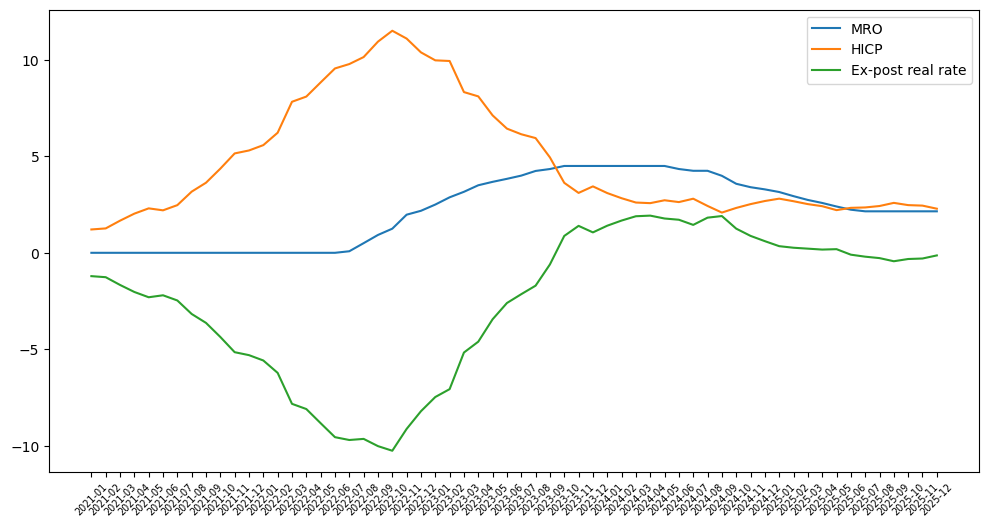

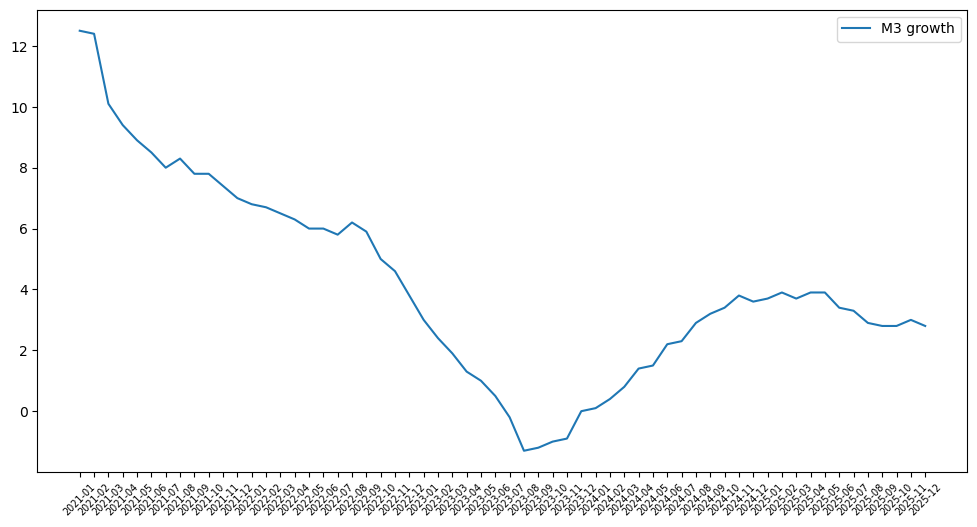

In [23]:
df_merged["ex_post_real_rate"] = df_merged["MRO"] - df_merged["HICP"]

#Make one figure with time series of mro, hicp, expost real rate

plt.figure(figsize=(12,6))
plt.plot(df_merged["Date"], df_merged["MRO"], label="MRO")
plt.plot(df_merged["Date"], df_merged["HICP"], label="HICP")
plt.plot(df_merged["Date"], df_merged["ex_post_real_rate"], label="Ex-post real rate")
plt.xticks(rotation=45,fontsize=7)
plt.legend()
plt.show()

plt.figure(figsize=(12,6))
plt.plot(df_merged["Date"], df_merged["M3_growth"], label="M3 growth")
plt.xticks(rotation=45,fontsize=7)
plt.legend()
plt.show()

# Regression

In [17]:
df_merged["d_MRO"] = df_merged["MRO"].diff()

L = 3

for l in range(L+1):    
    df_merged[f"d_MRO_lag{l}"] = df_merged["d_MRO"].shift(l)

for outcome in ["HICP", "UNRATE", "M3_growth"]:
    for l in range(1, L+1):
        df_merged[f"{outcome}_lag{l}"] = df_merged[outcome].shift(l)

In [18]:
import statsmodels.api as sm

outcomes = ["HICP", "UNRATE", "M3_growth"]

results = {}

for outcome in outcomes:
    # build list of regressor column names
    d_mro_cols   = [f"d_MRO_lag{l}"    for l in range(L+1)]
    outcome_lags = [f"{outcome}_lag{l}" for l in range(1, L+1)]
    
    X_cols = d_mro_cols + outcome_lags
    
    # drop rows with any NaN (created by diff and shift)
    data = df_merged[[outcome] + X_cols].dropna()
    
    y = data[outcome]
    X = sm.add_constant(data[X_cols])  # adds the intercept a
    
    model = sm.OLS(y, X).fit()
    results[outcome] = model
    
    print(f"\n{'='*60}")
    print(f"Outcome: {outcome}")
    print(model.summary())


Outcome: HICP
                            OLS Regression Results                            
Dep. Variable:                   HICP   R-squared:                       0.980
Model:                            OLS   Adj. R-squared:                  0.977
Method:                 Least Squares   F-statistic:                     338.8
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.33e-38
Time:                        16:04:12   Log-Likelihood:                -31.475
No. Observations:                  56   AIC:                             78.95
Df Residuals:                      48   BIC:                             95.15
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0557      0.193     

# 4. Crypto and gold

In [20]:
df_stoxx50 = pd.read_csv("data_raw/stoxx50.csv").rename(columns={"Date": "Date", "Price": "STOXX50"}).loc[:,["Date", "STOXX50"]]

# transform date from mm/dd/yyyy into forma yyyy-mm
df_stoxx50["Date"] = pd.to_datetime(df_stoxx50["Date"], format="%m/%d/%Y")
df_stoxx50["Date"] = df_stoxx50["Date"].dt.strftime("%Y-%m-%d")
if len(df_stoxx50["Date"].iloc[0])>=7:
    df_stoxx50["Date"]=df_stoxx50["Date"].apply(lambda x : x[0:7])

# make stoxx50 float values: for every value in stoxx50 first remove ","
df_stoxx50["STOXX50"] = df_stoxx50["STOXX50"].str.replace(",", "").astype(float)

df_merged = df_merged.merge(df_stoxx50[["STOXX50"]], left_index=True, right_index=True, how="left")


In [ ]:
import numpy as np
import statsmodels.api as sm

# compute log-returns
df_merged["r_BTC"]   = np.log(df_merged["BTC_price"]).diff()
df_merged["r_Gold"]  = np.log(df_merged["NASDAQQGLDI"]).diff()
df_merged["r_EQ"]    = np.log(df_merged["STOXX50"]).diff()
df_merged["d_MRO"]   = df_merged["MRO"].diff()
df_merged["trend"]   = np.arange(len(df_merged))

# run regression for each asset
assets = {"BTC": "r_BTC", "Gold": "r_Gold"}

results_cg = {}

for name, ret_col in assets.items():
    data = df_merged[["trend", "d_MRO", "HICP", "r_EQ", ret_col]].dropna()
    
    y = data[ret_col]
    X = sm.add_constant(data[["trend", "d_MRO", "HICP", "r_EQ"]])
    
    model = sm.OLS(y, X).fit(cov_type="HC1")
    results_cg[name] = model
    
    print(f"\n{'='*60}")
    print(f"Asset: {name}")
    print(model.summary().tables[1])


Asset: BTC
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1152      0.087      1.330      0.183      -0.055       0.285
trend      -1.791e-05      0.001     -0.012      0.990      -0.003       0.003
d_MRO          0.2387      0.141      1.693      0.090      -0.038       0.515
HICP          -0.0217      0.011     -2.027      0.043      -0.043      -0.001
r_EQ           0.4346      0.449      0.968      0.333      -0.446       1.315

Asset: Gold
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0092      0.010     -0.885      0.376      -0.030       0.011
trend          0.0005      0.000      2.819      0.005       0.000       0.001
d_MRO          0.0178      0.023      0.779      0.436      -0.027       0.063
HICP          -0.0016      

## Interpretation

### ECB Rate Hikes and the Economy

- **Inflation**: rate hikes don't reduce inflation quickly, no significant
  effect at 0–3 months. The main driver is persistence: last month's inflation
  almost fully predicts this month's (lag1 = 1.38), therefore once it goes up it
  tends to stay up.

- **Money supply (M3)**: shows the largest (though insignificant) response to rate changes at lag 1 (coefficient = −0.49, p = 0.268), suggesting potential slowing of money growth after one month, but this is not statistically significant.

- **Unemployment**: actually fell when rates rose, but this could be misleading,
  the ECB was hiking exactly when the labour market was recovering post-COVID.
  The two things could have coincided without causing each other.